# Week 13: Naive Bayes

## Setup and Data Loading

Importing libraries needed for Naive Bayes classification, including all three variants covered this week (Bernoulli, Multinomial, Gaussian), and loading the diabetes dataset used throughout this capstone.

In [1]:
import pandas as pd
import numpy as np
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, Binarizer
from sklearn.metrics import roc_auc_score

df = pd.read_csv('diabetes_binary_5050split_health_indicators_BRFSS2015.csv')
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


## Train/Test Split

Splitting the data 80/20, consistent with every prior week, to keep results comparable across models.

In [2]:
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(56553, 21)
(14139, 21)


## Gaussian Naive Bayes

Testing GaussianNB first, since it is designed for continuous features, which make up most of this dataset (BMI, MentHlth, PhysHlth, Age, Education, Income).

In [3]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)

y_pred_proba = gnb.predict_proba(X_test)[:, 1]
gnb_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Gaussian Naive Bayes AUC-ROC: {gnb_auc:.4f}")

Gaussian Naive Bayes AUC-ROC: 0.7861


## Bernoulli Naive Bayes

Testing BernoulliNB, which expects binary (present/not present) features. Since several features in this dataset are continuous (BMI, Age, etc.), binarizing the entire feature set at the median is needed to give this variant a fair test, following the binary/boolean feature description from this week's lesson.

In [4]:
binarizer = Binarizer(threshold=X_train.median().mean())
X_train_binary = X_train.apply(lambda col: (col > col.median()).astype(int))
X_test_binary = X_test.apply(lambda col: (col > X_train[col.name].median()).astype(int))

bnb = BernoulliNB()
bnb.fit(X_train_binary, y_train)

y_pred_proba = bnb.predict_proba(X_test_binary)[:, 1]
bnb_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Bernoulli Naive Bayes AUC-ROC: {bnb_auc:.4f}")

Bernoulli Naive Bayes AUC-ROC: 0.7602


## Multinomial Naive Bayes

Testing MultinomialNB, which expects non-negative count-like features. This dataset doesn't contain true word counts, but several features (GenHlth, MentHlth, PhysHlth, Age, Education, Income) are non-negative integer-coded scales, which MultinomialNB can still process, unlike features that could be negative after scaling.

In [5]:
mnb = MultinomialNB()
mnb.fit(X_train, y_train)

y_pred_proba = mnb.predict_proba(X_test)[:, 1]
mnb_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Multinomial Naive Bayes AUC-ROC: {mnb_auc:.4f}")

Multinomial Naive Bayes AUC-ROC: 0.6915


## Comparing All Three Naive Bayes Variants

GaussianNB performed best (AUC-ROC = 0.7861), followed by BernoulliNB (0.7602), with MultinomialNB performing worst (0.6915). This ordering makes sense given how well each variant's assumptions match this dataset: GaussianNB is designed for continuous features, which describe most of this dataset's columns (BMI, MentHlth, PhysHlth, Age, Education, Income) reasonably well. BernoulliNB required binarizing continuous features at the median, discarding real information (e.g., collapsing the difference between a BMI of 26 and 45 into a single "above median" flag), which likely explains its lower score. MultinomialNB assumes count-like data, such as word frequencies, and none of this dataset's features genuinely represent counts in that sense, even the integer-coded scales like GenHlth don't carry proportional meaning the way word counts do. All three scores also fall below every other model tested this capstone (gradient boost 0.8322, logistic regression 0.8232, random forest 0.8224, KNN 0.8198), which is consistent with the lesson's core caveat: Naive Bayes' feature independence assumption is a real simplification, and health indicators like BMI, blood pressure, and general health are realistically correlated with each other rather than independent.

 ## Would a Different Feature Subset Help MultinomialNB?

MultinomialNB assumes features behave like counts, where a higher value means proportionally "more" of something (e.g., a word appearing 4 times is meaningfully more than it appearing once). Testing whether restricting to the features that behave most like true counts or ordinal scales, rather than using all 21 features, improves MultinomialNB's performance.

In [6]:
count_like_features = ['GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']

X_train_subset = X_train[count_like_features]
X_test_subset = X_test[count_like_features]

mnb_subset = MultinomialNB()
mnb_subset.fit(X_train_subset, y_train)

y_pred_proba = mnb_subset.predict_proba(X_test_subset)[:, 1]
mnb_subset_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Multinomial Naive Bayes (count-like features only) AUC-ROC: {mnb_subset_auc:.4f}")
print(f"Multinomial Naive Bayes (all 21 features) AUC-ROC: {mnb_auc:.4f}")

Multinomial Naive Bayes (count-like features only) AUC-ROC: 0.6560
Multinomial Naive Bayes (all 21 features) AUC-ROC: 0.6915


## Finding: Feature Subsetting Did Not Help MultinomialNB

Contrary to the hypothesis, restricting MultinomialNB to only the six most count-like or ordinal features (GenHlth, MentHlth, PhysHlth, Age, Education, Income) performed worse (AUC-ROC = 0.6560) than using all 21 features (AUC-ROC = 0.6915). This suggests the binary flag features (HighBP, Smoker, Stroke, etc.), while not true counts, still contributed useful classification signal that MultinomialNB could extract, since a 0 versus a 1 still represents a meaningful difference in "amount" of that feature, even without proportional meaning. This indicates the core issue with MultinomialNB on this dataset is not simply which features are included, but a deeper mismatch between the algorithm's assumption that higher values proportionally mean "more" of something, and the reality that most of this dataset's features, including the ordinal scales, don't actually behave proportionally the way true word counts do. Removing more features did not fix this underlying mismatch, and in fact removed useful signal along with it.

## Overall Summary: Naive Bayes on This Dataset

Consolidating results from all four Naive Bayes tests this week for quick reference.

In [7]:
print("Naive Bayes Results Summary")
print(f"Gaussian Naive Bayes:                        {gnb_auc:.4f}")
print(f"Bernoulli Naive Bayes (median-binarized):     {bnb_auc:.4f}")
print(f"Multinomial Naive Bayes (all 21 features):    {mnb_auc:.4f}")
print(f"Multinomial Naive Bayes (6 count-like only):  {mnb_subset_auc:.4f}")
print()
print("Best performer: Gaussian Naive Bayes")
print("Best model overall this capstone: Gradient Boost (0.8322)")

Naive Bayes Results Summary
Gaussian Naive Bayes:                        0.7861
Bernoulli Naive Bayes (median-binarized):     0.7602
Multinomial Naive Bayes (all 21 features):    0.6915
Multinomial Naive Bayes (6 count-like only):  0.6560

Best performer: Gaussian Naive Bayes
Best model overall this capstone: Gradient Boost (0.8322)


## Visualizing the Comparison

Plotting all four Naive Bayes AUC-ROC results as a bar chart for a clear visual comparison, saved for potential use in Milestone Three.

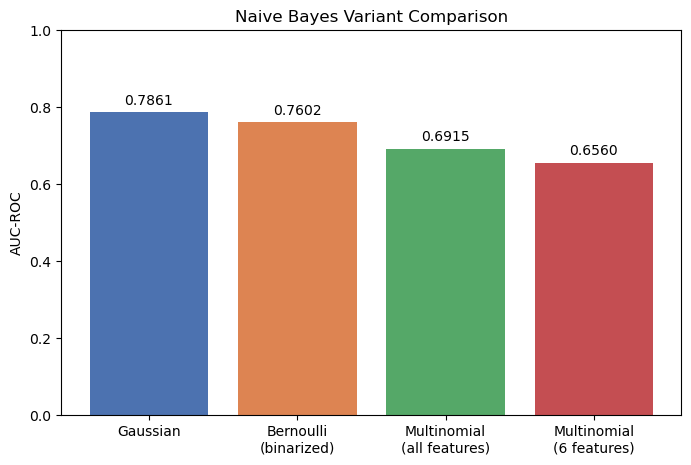

In [8]:
import matplotlib.pyplot as plt

labels = ['Gaussian', 'Bernoulli\n(binarized)', 'Multinomial\n(all features)', 'Multinomial\n(6 features)']
scores = [gnb_auc, bnb_auc, mnb_auc, mnb_subset_auc]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, scores, color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
plt.ylabel('AUC-ROC')
plt.title('Naive Bayes Variant Comparison')
plt.ylim(0, 1)

for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{score:.4f}', ha='center')

plt.savefig('week13_naive_bayes_comparison.png', dpi=300, bbox_inches='tight')
plt.show()